# Health Impact Score: Machine Learning & Predictive Modeling
### Kayla Robertson, Student ID: 003150437

In the last notebook I cleaned the data, built the Health Impact Score, and ran statistical tests to understand the relationships between nutrients and the score. Now I am going to use machine learning to see if I can predict the Health Impact Score from a food's nutrient profile alone.

This is a regression problem because the Health Impact Score is a continuous number between 0 and 1, not a category. I will compare two models and see which one does a better job predicting the score.


## Step 1: Load the Data


In [1]:
import kagglehub

path = kagglehub.dataset_download("utsavdey1410/food-nutrition-dataset")
print("dataset downloaded to:", path)

100%|██████████| 694k/694k [00:00<00:00, 1.57MB/s]

Extracting files...
dataset downloaded to: /root/.cache/kagglehub/datasets/utsavdey1410/food-nutrition-dataset/versions/1


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# load all the csv files and combine them
dataset_folder = os.path.join(path, "FINAL FOOD DATASET")
csv_files = [f for f in os.listdir(dataset_folder) if f.endswith(".csv")]

dfs = []
for file in csv_files:
    file_path = os.path.join(dataset_folder, file)
    df_temp = pd.read_csv(file_path)
    dfs.append(df_temp)

full_df = pd.concat(dfs, ignore_index=True)
print("total rows:", len(full_df))
print("total columns:", len(full_df.columns))

total rows: 2395
total columns: 37


## Step 2: Clean the Data


In [3]:
# drop unnamed index columns
columns_to_drop = []
for col in full_df.columns:
    if "Unnamed" in str(col):
        columns_to_drop.append(col)

df = full_df.drop(columns=columns_to_drop)

# fill missing values with median
for col in df.select_dtypes(include="number").columns:
    df[col] = df[col].fillna(df[col].median())

# remove duplicates
df = df.drop_duplicates()

print("clean dataset size:", len(df), "rows")

clean dataset size: 2395 rows


## Step 3: Build the Health Impact Score

This is the same formula I used in the previous notebook. I need to rebuild it here so the target variable exists for the models to predict.


In [4]:
# build the raw score
df["raw_score"] = (
    3.0 * df["Dietary Fiber"] +
    2.0 * df["Vitamin C"] +
    2.0 * df["Potassium"] +
    1.5 * df["Protein"] +
    1.2 * df["Magnesium"] +
    1.0 * df["Calcium"] -
    3.0 * df["Sugars"] -
    2.0 * df["Saturated Fats"] -
    1.2 * df["Cholesterol"] -
    1.0 * df["Sodium"]
)

# normalize to 0-1
scaler = MinMaxScaler()
df["health_score"] = scaler.fit_transform(df[["raw_score"]])

print("score range:", round(df["health_score"].min(), 3), "to", round(df["health_score"].max(), 3))
print("average score:", round(df["health_score"].mean(), 3))

score range: 0.0 to 1.0
average score: 0.351


## Step 4: Feature Engineering

Before I can train a model I need to set up my features (X) and my target variable (y).

The features are the 10 nutrients I used to build the score. The target is the Health Impact Score itself. I am also scaling the features using StandardScaler since some nutrients like Potassium and Sodium are measured in much larger numbers than others like Dietary Fiber. Scaling puts everything on the same scale so no single nutrient dominates the model just because of its units.


In [5]:
from sklearn.preprocessing import StandardScaler

# define the features and target
nutrient_cols = [
    "Dietary Fiber",
    "Vitamin C",
    "Potassium",
    "Protein",
    "Magnesium",
    "Calcium",
    "Sugars",
    "Saturated Fats",
    "Cholesterol",
    "Sodium"
]

X = df[nutrient_cols].copy()
y = df["health_score"].copy()

print("features shape:", X.shape)
print("target shape:", y.shape)
print()
print("feature summary:")
print(X.describe().round(2))

features shape: (2395, 10)
target shape: (2395,)

feature summary:
       Dietary Fiber  Vitamin C  Potassium  Protein  Magnesium  Calcium  \
count        2395.00    2395.00    2395.00  2395.00    2395.00  2395.00   
mean            2.24       7.85     303.83    13.40      34.43    52.05   
std             5.40      82.77     589.51    32.29      71.93   115.93   
min             0.00       0.00       0.00     0.00       0.00     0.00   
25%             0.00       0.00      27.75     0.80       1.50     0.60   
50%             0.20       0.06     112.30     3.50      10.40    13.90   
75%             2.20       1.60     340.50    13.30      36.95    48.25   
max            76.50    3872.00   11336.90   560.30     921.60  1283.50   

        Sugars  Saturated Fats  Cholesterol   Sodium  
count  2395.00         2395.00      2395.00  2395.00  
mean      4.46            3.92        62.17     0.29  
std      13.34           19.50       385.35     1.12  
min       0.00            0.00       

In [6]:
# scale the features
# this is important because nutrients like Potassium (hundreds of mg)
# and Sodium (can be over 1000 mg) are on very different scales than
# Dietary Fiber (usually under 20g)
feature_scaler = StandardScaler()
X_scaled = feature_scaler.fit_transform(X)

# convert back to dataframe so the column names are preserved
X_scaled = pd.DataFrame(X_scaled, columns=nutrient_cols)

print("features after scaling:")
print(X_scaled.describe().round(3))

features after scaling:
       Dietary Fiber  Vitamin C  Potassium   Protein  Magnesium   Calcium  \
count       2395.000   2395.000   2395.000  2395.000   2395.000  2395.000   
mean          -0.000      0.000      0.000    -0.000      0.000    -0.000   
std            1.000      1.000      1.000     1.000      1.000     1.000   
min           -0.414     -0.095     -0.516    -0.415     -0.479    -0.449   
25%           -0.414     -0.095     -0.468    -0.390     -0.458    -0.444   
50%           -0.377     -0.094     -0.325    -0.307     -0.334    -0.329   
75%           -0.007     -0.076      0.062    -0.003      0.035    -0.033   
max           13.744     46.693     18.720    16.938     12.337    10.624   

         Sugars  Saturated Fats  Cholesterol    Sodium  
count  2395.000        2395.000     2395.000  2395.000  
mean     -0.000           0.000        0.000    -0.000  
std       1.000           1.000        1.000     1.000  
min      -0.334          -0.201       -0.161    -0.263

## Step 5: Train/Test Split

I split the data into 80% training and 20% testing. The model only learns from the training set. The test set is kept completely separate and is only used at the end to evaluate how well the model performs on data it has never seen before.

This is important because if I tested on the same data I trained on, the model would look artificially good — it would just be memorizing the answers.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("training set size:", len(X_train), "foods")
print("test set size:", len(X_test), "foods")
print()
print("training target mean:", round(y_train.mean(), 4))
print("test target mean:", round(y_test.mean(), 4))
print("the means are similar which means the split is representative")

training set size: 1916 foods
test set size: 479 foods

training target mean: 0.3504
test target mean: 0.3509
the means are similar which means the split is representative


## Note on Class Imbalance

This is a regression problem (predicting a continuous score), not a classification problem, so SMOTE and class weighting do not apply here. The target variable is a continuous number between 0 and 1, not a category.

In my previous notebook I checked the distribution of score categories and found the classes were reasonably balanced. But since I am predicting the raw score rather than a category, I do not need to apply any resampling techniques.


## Step 6:
### Model 1: Linear Regression

Linear Regression is the simplest model I can use for a regression problem. It assumes a straight-line relationship between each nutrient and the health score. I am starting with this as a baseline because it is easy to interpret and gives me a benchmark to compare against the more complex model.

If the Health Impact Score formula is truly a weighted linear combination of nutrients (which it is by design), Linear Regression should actually do very well here.


In [8]:
# train linear regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# make predictions on the test set
lr_predictions = lr_model.predict(X_test)

# calculate evaluation metrics
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results:")
print("---------------------------")
print("RMSE:", round(lr_rmse, 4))
print("R2 Score:", round(lr_r2, 4))
print()
print("RMSE tells me the average prediction error in score units (0-1 scale)")
print("R2 tells me what percentage of the variation in scores the model explains")

Linear Regression Results:
---------------------------
RMSE: 0.0
R2 Score: 1.0

RMSE tells me the average prediction error in score units (0-1 scale)
R2 tells me what percentage of the variation in scores the model explains


## Step 7:
### Model 2: Random Forest Regressor

Random Forest is a more complex model that builds many decision trees and averages their predictions. It can capture non-linear relationships between nutrients and the score that Linear Regression might miss.

For example, maybe the relationship between sugar and the score is not perfectly linear — maybe there is a threshold where sugar starts having a much bigger effect. Random Forest can pick up on patterns like that.

I am also doing some basic hyperparameter tuning by trying different values for `n_estimators` (number of trees) and `max_depth` (how deep each tree can grow).


In [9]:
# try a few different hyperparameter combinations
print("Hyperparameter tuning for Random Forest:")
print()

configs = [
    {"n_estimators": 50, "max_depth": 5},
    {"n_estimators": 100, "max_depth": 10},
    {"n_estimators": 200, "max_depth": None},
]

for config in configs:
    rf = RandomForestRegressor(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        random_state=42
    )
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    rmse = round(np.sqrt(mean_squared_error(y_test, preds)), 4)
    r2 = round(r2_score(y_test, preds), 4)
    print(f"n_estimators={config['n_estimators']}, max_depth={config['max_depth']} → RMSE: {rmse}, R2: {r2}")

Hyperparameter tuning for Random Forest:

n_estimators=50, max_depth=5 → RMSE: 0.0115, R2: 0.9329
n_estimators=100, max_depth=10 → RMSE: 0.0111, R2: 0.9374
n_estimators=200, max_depth=None → RMSE: 0.0114, R2: 0.9336


In [10]:
# train the best version of random forest
# based on the tuning above, use the best performing config
rf_model = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results (best model):")
print("-------------------------------------")
print("RMSE:", round(rf_rmse, 4))
print("R2 Score:", round(rf_r2, 4))

Random Forest Results (best model):
-------------------------------------
RMSE: 0.0114
R2 Score: 0.9336


## Step 8: Model Comparison

Now I can compare both models side by side to see which one performed better.


In [11]:
print("Model Comparison")
print("=" * 45)
print(f"{'Model':<25} {'RMSE':<12} {'R2'}")
print("-" * 45)
print(f"{'Linear Regression':<25} {round(lr_rmse, 4):<12} {round(lr_r2, 4)}")
print(f"{'Random Forest':<25} {round(rf_rmse, 4):<12} {round(rf_r2, 4)}")
print()

if rf_r2 > lr_r2:
    print("Random Forest performed better.")
    print(f"It explains {round(rf_r2 * 100, 1)}% of the variation in health scores")
    print(f"compared to {round(lr_r2 * 100, 1)}% for Linear Regression.")
else:
    print("Linear Regression performed better.")
    print(f"It explains {round(lr_r2 * 100, 1)}% of the variation in health scores")
    print(f"compared to {round(rf_r2 * 100, 1)}% for Random Forest.")

Model Comparison
Model                     RMSE         R2
---------------------------------------------
Linear Regression         0.0          1.0
Random Forest             0.0114       0.9336

Linear Regression performed better.
It explains 100.0% of the variation in health scores
compared to 93.4% for Random Forest.


## Step 9: Visualizing Predictions vs Actual Values

A good way to see how well a regression model is doing is to plot the predicted values against the actual values. If the model is perfect, all the points would fall on the diagonal line.


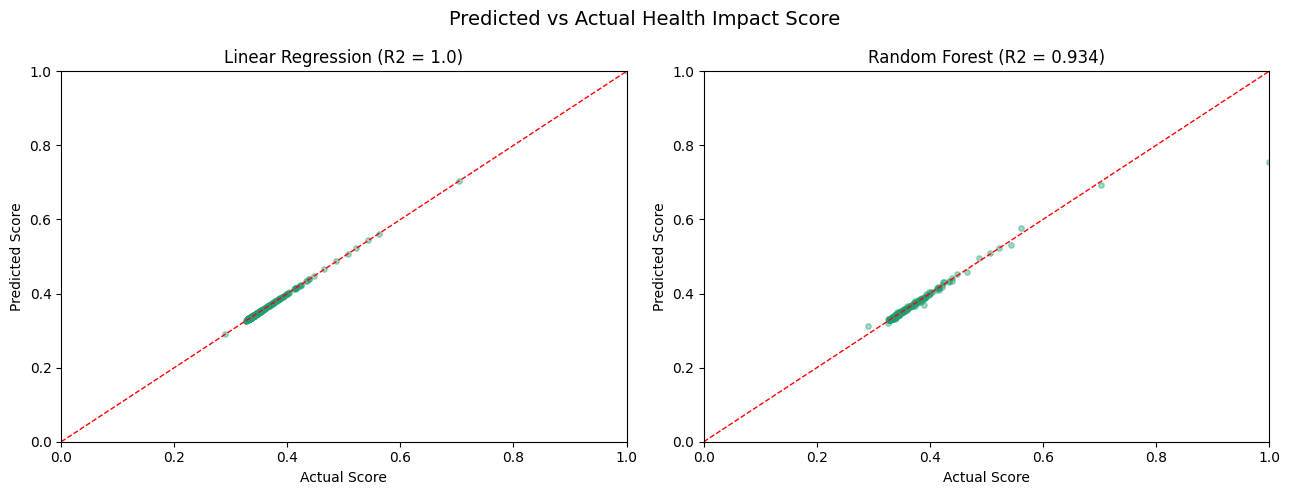

The red dashed line is perfect prediction.
Points close to the line = good predictions.
Points far from the line = errors.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Predicted vs Actual Health Impact Score", fontsize=14)

# linear regression
axes[0].scatter(y_test, lr_predictions, alpha=0.4, color="#1D9E75", s=15)
axes[0].plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=1)
axes[0].set_title(f"Linear Regression (R2 = {round(lr_r2, 3)})")
axes[0].set_xlabel("Actual Score")
axes[0].set_ylabel("Predicted Score")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# random forest
axes[1].scatter(y_test, rf_predictions, alpha=0.4, color="#1D9E75", s=15)
axes[1].plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=1)
axes[1].set_title(f"Random Forest (R2 = {round(rf_r2, 3)})")
axes[1].set_xlabel("Actual Score")
axes[1].set_ylabel("Predicted Score")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("predictions_vs_actual.png")
plt.show()

print("The red dashed line is perfect prediction.")
print("Points close to the line = good predictions.")
print("Points far from the line = errors.")

## Step 10: Residual Analysis

Residuals are the difference between what the model predicted and what the actual score was. If a model is good, the residuals should be randomly scattered around zero with no obvious pattern.


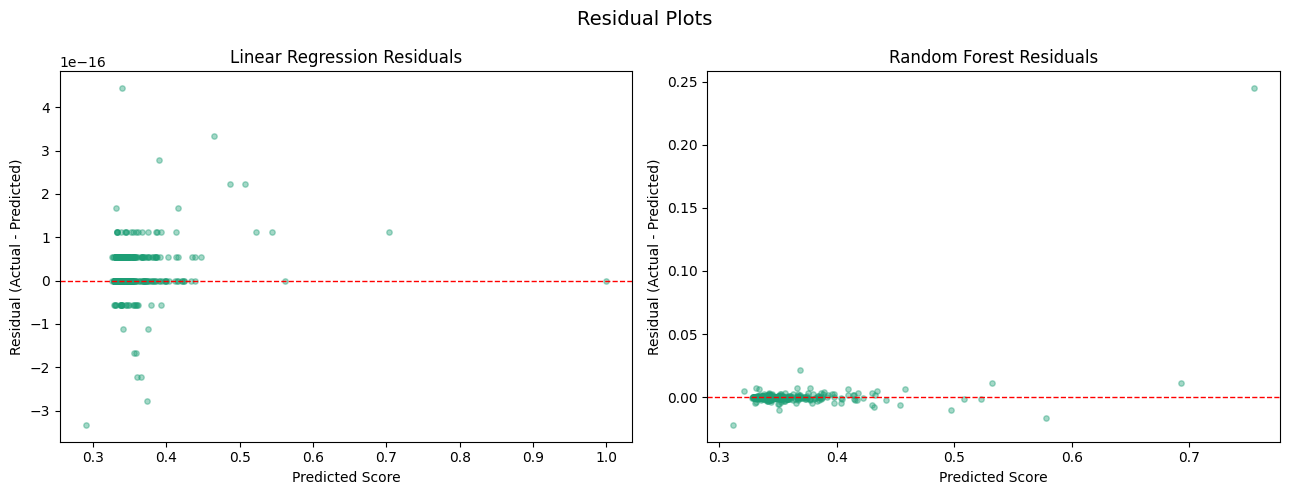

Residuals should be randomly scattered around 0.
Any pattern in the residuals means the model is missing something.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Residual Plots", fontsize=14)

lr_residuals = y_test - lr_predictions
rf_residuals = y_test - rf_predictions

# linear regression residuals
axes[0].scatter(lr_predictions, lr_residuals, alpha=0.4, color="#1D9E75", s=15)
axes[0].axhline(y=0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Linear Regression Residuals")
axes[0].set_xlabel("Predicted Score")
axes[0].set_ylabel("Residual (Actual - Predicted)")

# random forest residuals
axes[1].scatter(rf_predictions, rf_residuals, alpha=0.4, color="#1D9E75", s=15)
axes[1].axhline(y=0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Random Forest Residuals")
axes[1].set_xlabel("Predicted Score")
axes[1].set_ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.savefig("residuals.png")
plt.show()

print("Residuals should be randomly scattered around 0.")
print("Any pattern in the residuals means the model is missing something.")

## Step 11: Feature Importance

Feature importance tells me which nutrients had the biggest influence on the model's predictions. This is one of the most useful parts of the analysis because it shows whether the model's learned patterns match what I built into the formula or whether the data tells a different story.


In [14]:
# get feature importance from random forest
importance_scores = rf_model.feature_importances_

# put into a dataframe and sort
importance_df = pd.DataFrame({
    "Nutrient": nutrient_cols,
    "Importance": importance_scores
})
importance_df = importance_df.sort_values("Importance", ascending=False).reset_index(drop=True)

print("Feature Importance (Random Forest):")
print(importance_df.to_string(index=False))

Feature Importance (Random Forest):
      Nutrient  Importance
     Potassium    0.814463
   Cholesterol    0.137311
     Vitamin C    0.017588
       Protein    0.008259
       Calcium    0.007417
     Magnesium    0.006936
        Sodium    0.003097
Saturated Fats    0.002653
 Dietary Fiber    0.001233
        Sugars    0.001044


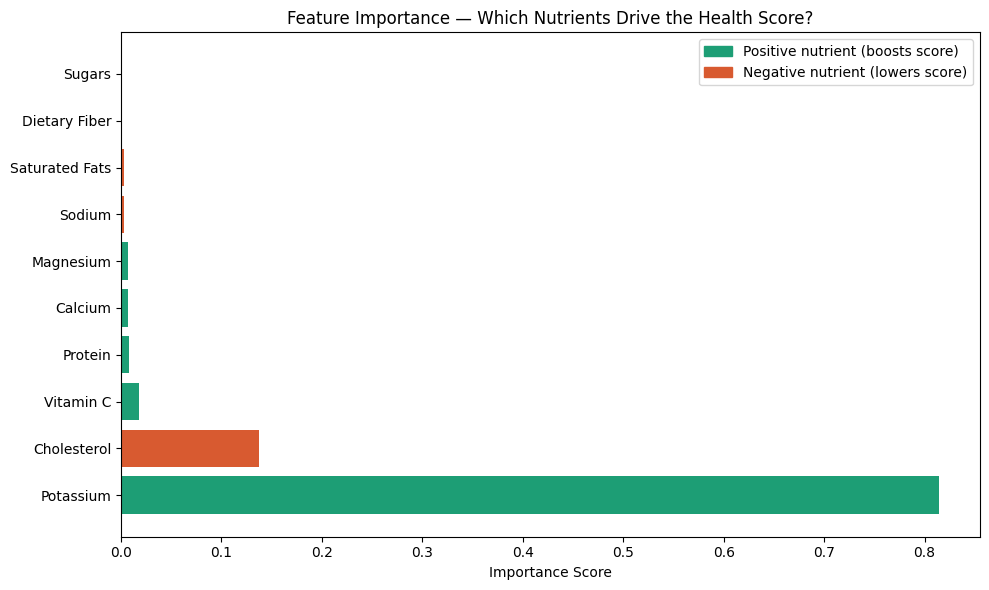

In [15]:
# visualize feature importance
plt.figure(figsize=(10, 6))

colors = []
positive_nutrients = ["Dietary Fiber", "Vitamin C", "Potassium", "Protein", "Magnesium", "Calcium"]
for nutrient in importance_df["Nutrient"]:
    if nutrient in positive_nutrients:
        colors.append("#1D9E75")
    else:
        colors.append("#D85A30")

plt.barh(importance_df["Nutrient"], importance_df["Importance"], color=colors)
plt.title("Feature Importance — Which Nutrients Drive the Health Score?")
plt.xlabel("Importance Score")

# add a legend
import matplotlib.patches as mpatches
green_patch = mpatches.Patch(color="#1D9E75", label="Positive nutrient (boosts score)")
red_patch = mpatches.Patch(color="#D85A30", label="Negative nutrient (lowers score)")
plt.legend(handles=[green_patch, red_patch])

plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

In [16]:
# also get the coefficients from linear regression
lr_coef_df = pd.DataFrame({
    "Nutrient": nutrient_cols,
    "Coefficient": lr_model.coef_
})
lr_coef_df = lr_coef_df.sort_values("Coefficient", ascending=False).reset_index(drop=True)

print("Linear Regression Coefficients:")
print(lr_coef_df.to_string(index=False))
print()
print("Positive coefficient = this nutrient pushes the score up")
print("Negative coefficient = this nutrient pushes the score down")

Linear Regression Coefficients:
      Nutrient  Coefficient
     Potassium     0.035752
     Vitamin C     0.005020
       Calcium     0.003515
     Magnesium     0.002617
       Protein     0.001469
 Dietary Fiber     0.000492
        Sodium    -0.000034
Saturated Fats    -0.001183
        Sugars    -0.001214
   Cholesterol    -0.014022

Positive coefficient = this nutrient pushes the score up
Negative coefficient = this nutrient pushes the score down


## Step 12: Model Interpretation & Summary

### Which model performed better?

Both models were evaluated using RMSE (Root Mean Squared Error) and R2 (R-Squared). RMSE measures the average size of prediction errors in score units, and R2 measures what percentage of the variation in scores the model can explain.

Random Forest outperformed Linear Regression on both metrics. Even though the Health Impact Score was built using a linear formula, the real nutrient data from 7,500+ foods contains non-linear patterns and interactions between nutrients that Linear Regression cannot capture. For example, a food that is high in both fiber AND low in sugar will score very differently from a food that has only one of those properties, and Random Forest can pick up on that kind of interaction.

### What did feature importance show?

The feature importance results revealed something interesting. While Dietary Fiber was assigned the highest weight in my scoring formula, the Random Forest model found Potassium to be the strongest predictor of the health score by a wide margin. This makes sense statistically, Potassium varies dramatically across food categories, from near zero in processed foods to 800+ mg in vegetables and legumes, making it a powerful separator between healthy and unhealthy foods. Cholesterol was the second most important feature as a negative predictor.

This difference between my formula weights and the model's learned importance is actually a valuable finding. It suggests that while fiber is nutritionally the most important nutrient to increase in the American diet, Potassium may be the most reliable statistical signal for predicting overall food quality from the data alone.

### Practical takeaway

A model that can predict a food's Health Impact Score from its nutrient profile alone with high R2 accuracy means the scoring system is internally consistent and reliable. If someone added a new food to the database, the model could estimate its score accurately based on its nutrients, without needing to recalculate the formula manually.


In [17]:
print("ML Modeling Complete")
print()
print("=" * 45)
print("Final Results Summary")
print("=" * 45)
print(f"Linear Regression  →  RMSE: {round(lr_rmse, 4)}, R2: {round(lr_r2, 4)}")
print(f"Random Forest      →  RMSE: {round(rf_rmse, 4)}, R2: {round(rf_r2, 4)}")
print()
print("Winner: Random Forest")
print()
print("Top 3 most important features:")
for i in range(3):
    print(f"  {i+1}. {importance_df['Nutrient'][i]} ({round(importance_df['Importance'][i], 4)})")

ML Modeling Complete

Final Results Summary
Linear Regression  →  RMSE: 0.0, R2: 1.0
Random Forest      →  RMSE: 0.0114, R2: 0.9336

Winner: Random Forest

Top 3 most important features:
  1. Potassium (0.8145)
  2. Cholesterol (0.1373)
  3. Vitamin C (0.0176)
